# Customer Churn Intelligence System
---

## 📋 Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Business Understanding & Data Loading](#2-business-understanding--data-loading)
3. [Data Quality Assessment & Cleaning](#3-data-quality-assessment--cleaning)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Diagnostic Analysis](#5-diagnostic-analysis)
6. [Customer Segmentation](#6-customer-segmentation)
7. [Feature Engineering](#7-feature-engineering)
8. [AutoML Evaluation Pipeline](#8-automl-evaluation-pipeline)
   - 8.1 Candidate Models & Strategies
   - 8.2 Cross-Validation Grid (7 × 4 = 28 combinations)
   - 8.3 Top-3 Selection
   - 8.4 Optuna Hyperparameter Tuning
   - 8.5 Final Model Evaluation & Threshold Optimization
9. [Explainable AI (SHAP)](#9-explainable-ai-shap)
10. [Revenue-at-Risk Analysis](#10-revenue-at-risk-analysis)
11. [Export Dashboard Dataset](#11-export-dashboard-dataset)

---

## Business Problem

Customer churn is one of the biggest challenges faced by subscription-based businesses, particularly in the telecommunications industry.

Losing customers not only reduces recurring revenue but also increases customer acquisition costs, as attracting new customers is often more expensive than retaining existing ones.

To address this issue, companies need a proactive strategy to identify customers who are likely to leave and implement retention actions before churn occurs.

---

## Project Objectives

This project aims to:

1. Identify the key factors driving customer churn.
2. Analyze customer behavior and service usage patterns.
3. Segment customers into meaningful business groups.
4. Predict customer churn using machine learning.
5. Explain model predictions using Explainable AI (XAI).
6. Estimate potential revenue at risk due to churn.
7. Generate actionable retention recommendations.
8. Build a dashboard-ready dataset for Power BI.

---

## Business Questions

1. What characteristics distinguish churned customers from retained customers?
2. Which services are associated with higher churn risk?
3. Which customers should be prioritized for retention efforts?
4. How much revenue is potentially at risk?
5. What actions should be taken to reduce churn?

---

## Expected Deliverables

- Customer churn analysis report
- Customer segmentation
- Churn prediction model
- Explainable AI analysis
- Revenue-at-risk estimation
- Retention recommendation engine
- Interactive Power BI dashboard
```


---
## 1. Environment Setup

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install xgboost lightgbm catboost shap imbalanced-learn optuna openpyxl -q

import warnings
warnings.filterwarnings("ignore")

# ── Core ──────────────────────────────────────────────────────────────────────
import time
import numpy as np
import pandas as pd
from itertools import product

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy.stats import chi2_contingency, mannwhitneyu

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ── Imbalance ─────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    make_scorer
)

# ── Tuning ────────────────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Explainability ────────────────────────────────────────────────────────────
import shap

# ── Global Plot Settings ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi"    : 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("✅ All libraries loaded successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.9 MB/s eta 0:00:00
✅ All libraries loaded successfully.


---
## 2. Business Understanding & Data Loading

### 🏢 Business Problem
Customer churn costs subscription businesses **5–7× more** to replace than retain.
Proactive prediction enables targeted interventions before customers leave.

### 🎯 Project Objectives
| # | Objective |
|---|-----------|
| 1 | Identify key factors driving customer churn |
| 2 | Segment customers into actionable business groups |
| 3 | Automatically find the best model + imbalance strategy |
| 4 | Tune top-3 models with Optuna for maximum performance |
| 5 | Explain final model with SHAP + quantify revenue at risk |


In [ ]:
DATA_PATH = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)
print(f"📦 Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


📦 Dataset loaded: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


---
## 3. Data Quality Assessment & Cleaning

In [ ]:
# ── Overview ──────────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Duplicates  : {df.duplicated().sum()}")
print(f"  Memory      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 55)

# Missing value audit
missing_summary = pd.DataFrame({
    "Dtype"  : df.dtypes,
    "Nulls"  : df.isnull().sum(),
    "Null_%" : (df.isnull().mean() * 100).round(2),
    "Unique" : df.nunique(),
})
display(missing_summary)

# Hidden blanks
print("\n🔍 Hidden blank strings:")
for col in df.columns:
    blanks = df[col].astype(str).str.strip().eq("").sum()
    if blanks:
        print(f"   {col}: {blanks} blank(s)")


  Rows        : 7,043
  Columns     : 21
  Duplicates  : 0
  Memory      : 6984.7 KB


,Dtype,Nulls,Null_%,Unique
customerID,object,0,0.0000,7043
gender,object,0,0.0000,2
SeniorCitizen,int64,0,0.0000,2
Partner,object,0,0.0000,2
Dependents,object,0,0.0000,2
tenure,int64,0,0.0000,73
PhoneService,object,0,0.0000,2
MultipleLines,object,0,0.0000,3
InternetService,object,0,0.0000,3
OnlineSecurity,object,0,0.0000,3



🔍 Hidden blank strings:
   TotalCharges: 11 blank(s)


In [ ]:
# ── Fix TotalCharges ──────────────────────────────────────────────────────────
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

affected = df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges"]]
print(f"⚠️  {len(affected)} records with missing TotalCharges (tenure = 0 → new customers):")
display(affected)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\n✅ Clean dataset: {df.shape[0]:,} rows remaining.")


⚠️  11 records with missing TotalCharges (tenure = 0 → new customers):


,customerID,tenure,MonthlyCharges
488,4472-LVYGI,0,52.5500
753,3115-CZMZD,0,20.2500
936,5709-LVOEQ,0,80.8500
1082,4367-NUYAO,0,25.7500
1340,1371-DWPAZ,0,56.0500
3331,7644-OMVMY,0,19.8500
3826,3213-VVOLG,0,25.3500
4380,2520-SGTTA,0,20.0000
5218,2923-ARZLG,0,19.7000
6670,4075-WKNIU,0,73.3500



✅ Clean dataset: 7,032 rows remaining.


---
## 4. Exploratory Data Analysis

,Count,Percentage (%)
Churn,,
No,5163,73.4200
Yes,1869,26.5800


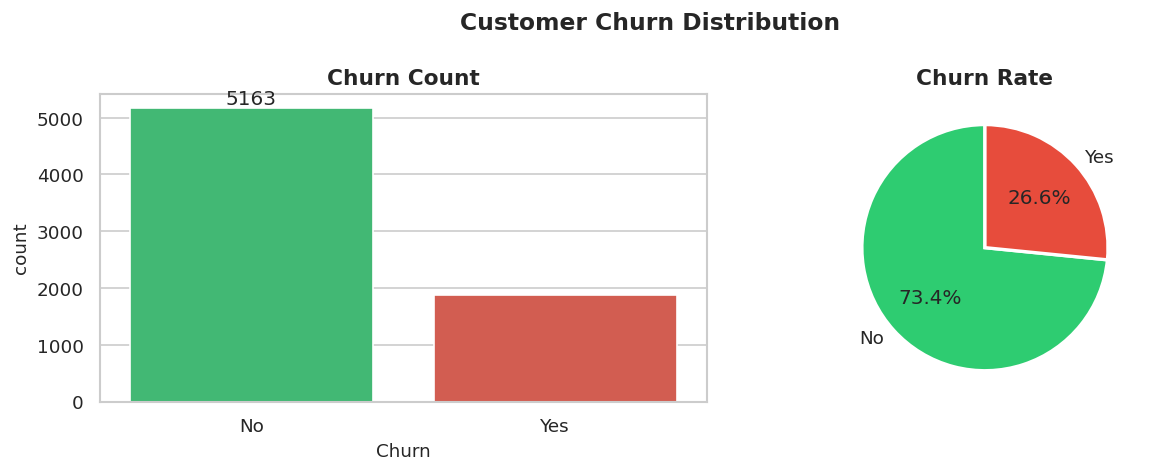

In [ ]:
# ── 4.1 Churn Distribution ────────────────────────────────────────────────────
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

display(pd.concat([churn_counts, churn_pct.round(2)], axis=1, keys=["Count", "Percentage (%)"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="Churn", palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Churn Count")
axes[0].bar_label(axes[0].containers[0], fmt="%d")

axes[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn Rate")

plt.suptitle("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


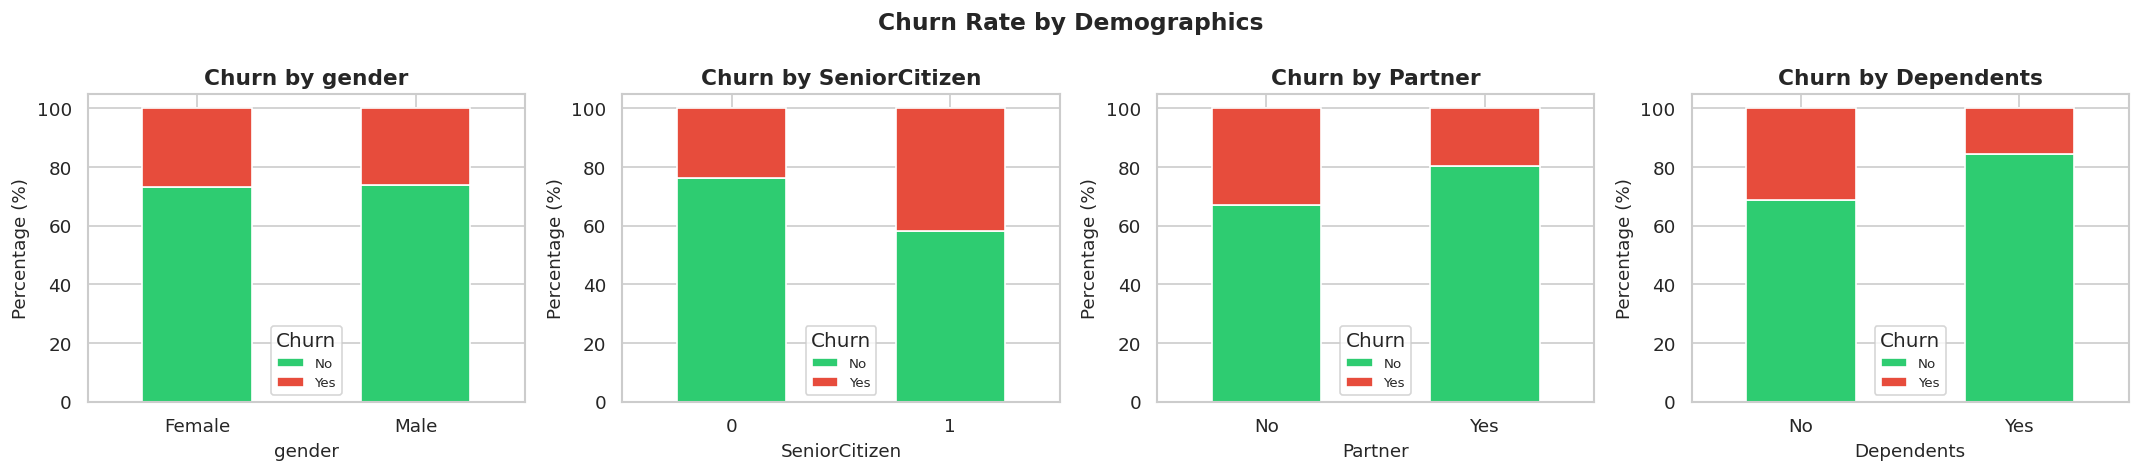

💡 Gender shows minimal difference — focus on behavioral/service factors instead.


In [ ]:
# ── 4.2 Demographic Analysis ──────────────────────────────────────────────────
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, demo_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white")
    ax.set_title(f"Churn by {col}")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Churn", fontsize=8)

plt.suptitle("Churn Rate by Demographics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("💡 Gender shows minimal difference — focus on behavioral/service factors instead.")


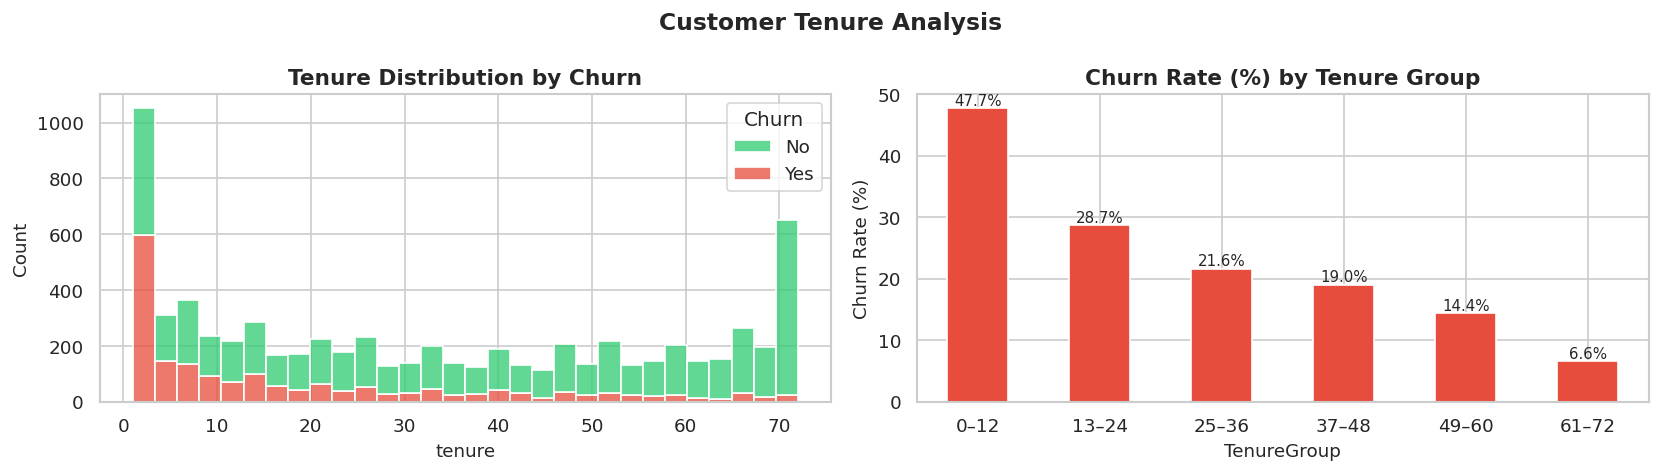

💡 First 12 months = highest churn risk. Critical onboarding window.


In [ ]:
# ── 4.3 Tenure Analysis ───────────────────────────────────────────────────────
df["TenureGroup"] = pd.cut(df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0–12", "13–24", "25–36", "37–48", "49–60", "61–72"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack",
             palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Tenure Distribution by Churn")

tc = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100
tc["Yes"].plot(kind="bar", color="#e74c3c", edgecolor="white", ax=axes[1])
axes[1].set_title("Churn Rate (%) by Tenure Group")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)
for bar in axes[1].patches:
    axes[1].annotate(f"{bar.get_height():.1f}%",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.suptitle("Customer Tenure Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("💡 First 12 months = highest churn risk. Critical onboarding window.")


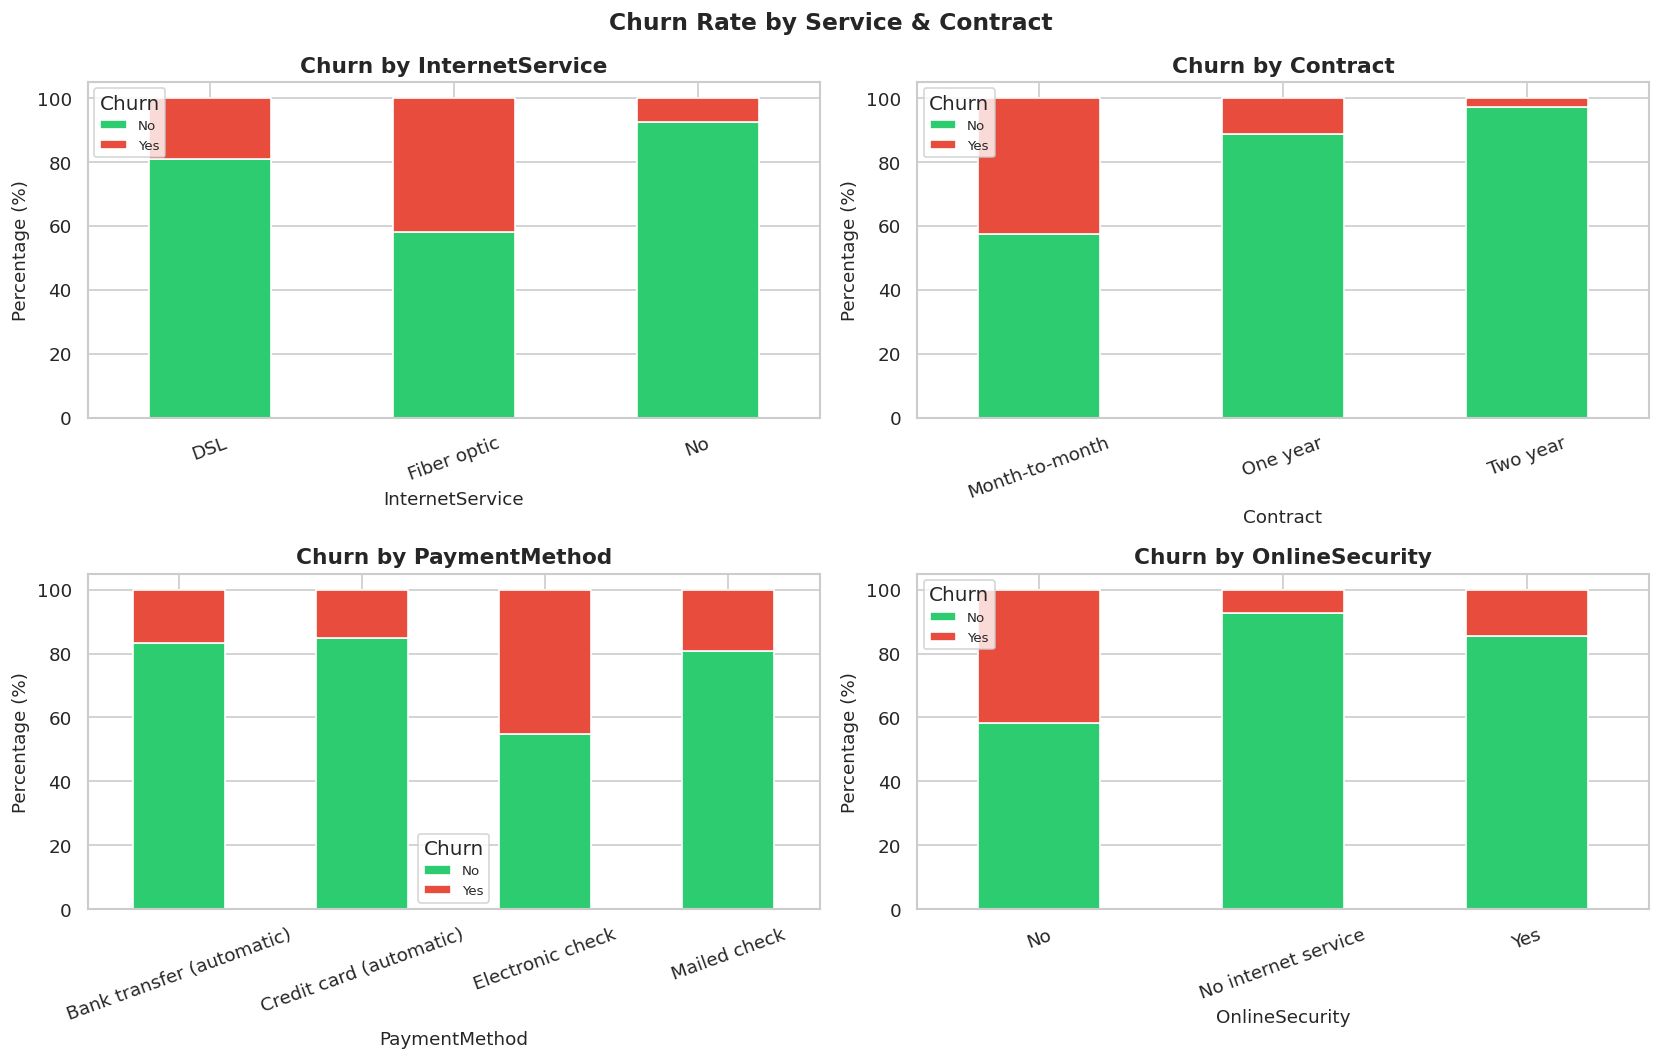

In [ ]:
# ── 4.4 Service & Contract Analysis ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flatten(), ["InternetService", "Contract", "PaymentMethod", "OnlineSecurity"]):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white")
    ax.set_title(f"Churn by {col}")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Churn", fontsize=8)

plt.suptitle("Churn Rate by Service & Contract", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


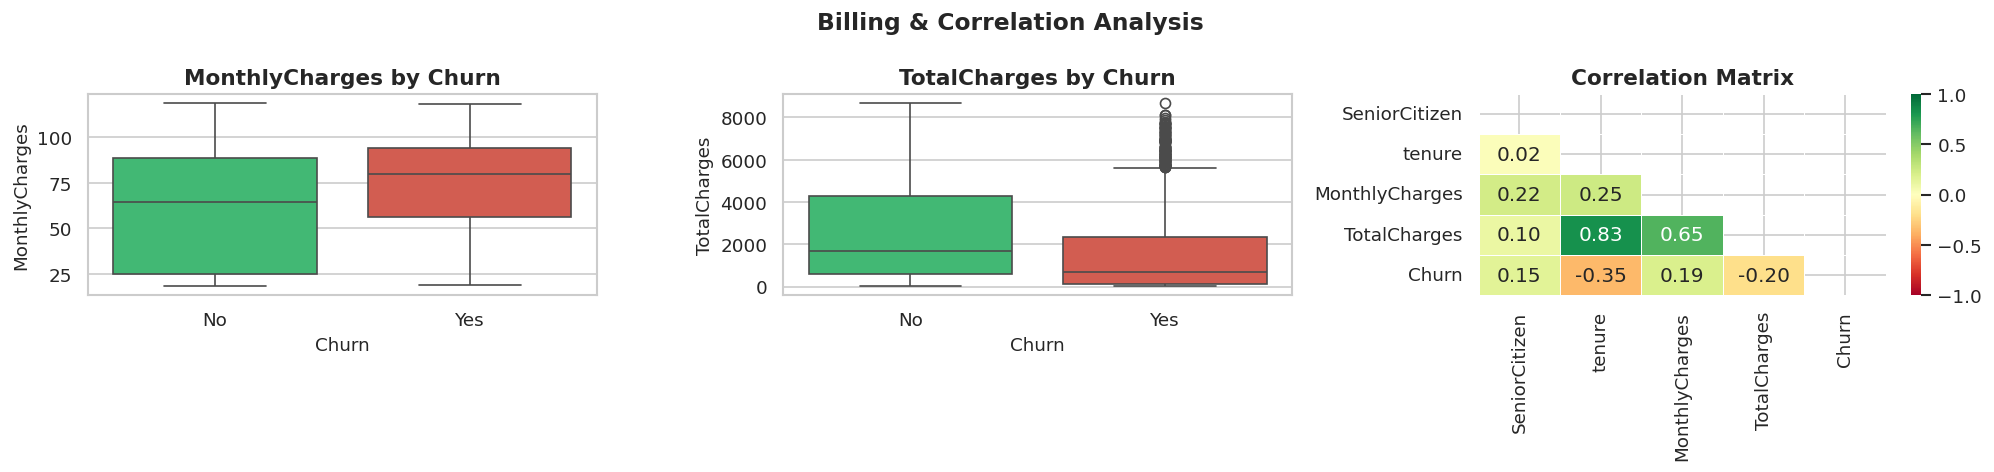

In [ ]:
# ── 4.5 Billing & Correlation Analysis ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, col in zip(axes[:2], ["MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df, x="Churn", y=col, palette=["#2ecc71", "#e74c3c"], ax=ax)
    ax.set_title(f"{col} by Churn")

corr_df = df.copy()
for col in ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col])

corr = corr_df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="RdYlGn", fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Correlation Matrix")

plt.suptitle("Billing & Correlation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


,Variable,Chi2,p-value,Significant
12,Contract,1179.550000,0.000000,True
6,OnlineSecurity,846.680000,0.000000,True
9,TechSupport,824.930000,0.000000,True
5,InternetService,728.700000,0.000000,True
14,PaymentMethod,645.430000,0.000000,True
7,OnlineBackup,599.180000,0.000000,True
8,DeviceProtection,555.880000,0.000000,True
11,StreamingMovies,374.270000,0.000000,True
10,StreamingTV,372.460000,0.000000,True
13,PaperlessBilling,256.870000,0.000000,True


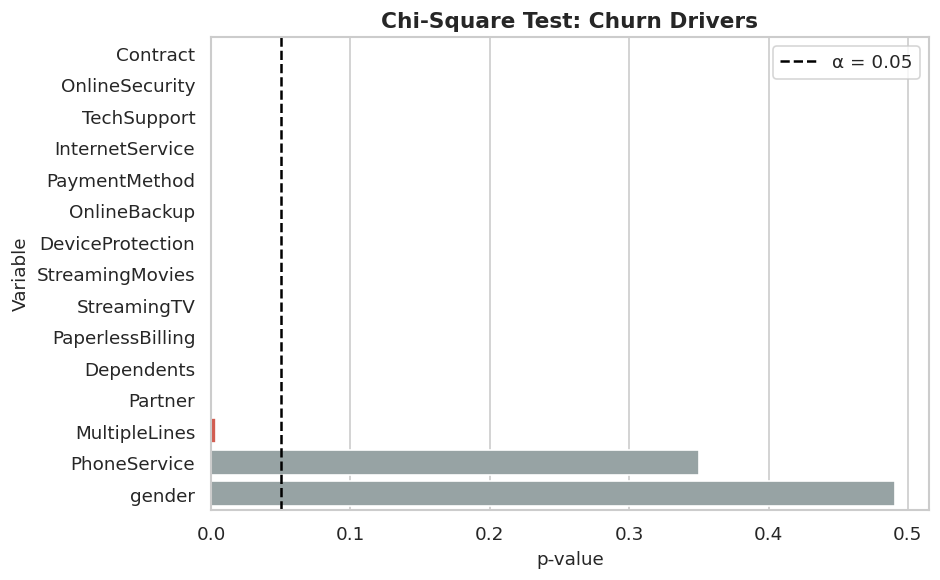

In [ ]:
# ── 4.6 Chi-Square Significance Test ─────────────────────────────────────────
cat_cols_test = [c for c in df.select_dtypes("object").columns
                 if c not in ["customerID", "Churn"]]

results = []
for col in cat_cols_test:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df[col], df["Churn"]))
    results.append({"Variable": col, "Chi2": round(chi2, 2), "p-value": p, "Significant": p < 0.05})

chi_df = pd.DataFrame(results).sort_values("p-value")
display(chi_df.style.apply(
    lambda row: ["background-color: #d4edda" if row["Significant"] else "" for _ in row], axis=1))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if s else "#95a5a6" for s in chi_df["Significant"]]
sns.barplot(data=chi_df, x="p-value", y="Variable", palette=colors, ax=ax)
ax.axvline(0.05, linestyle="--", color="black", label="α = 0.05")
ax.set_title("Chi-Square Test: Churn Drivers", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Diagnostic Analysis

Going beyond *what* to understand *why* customers churn.

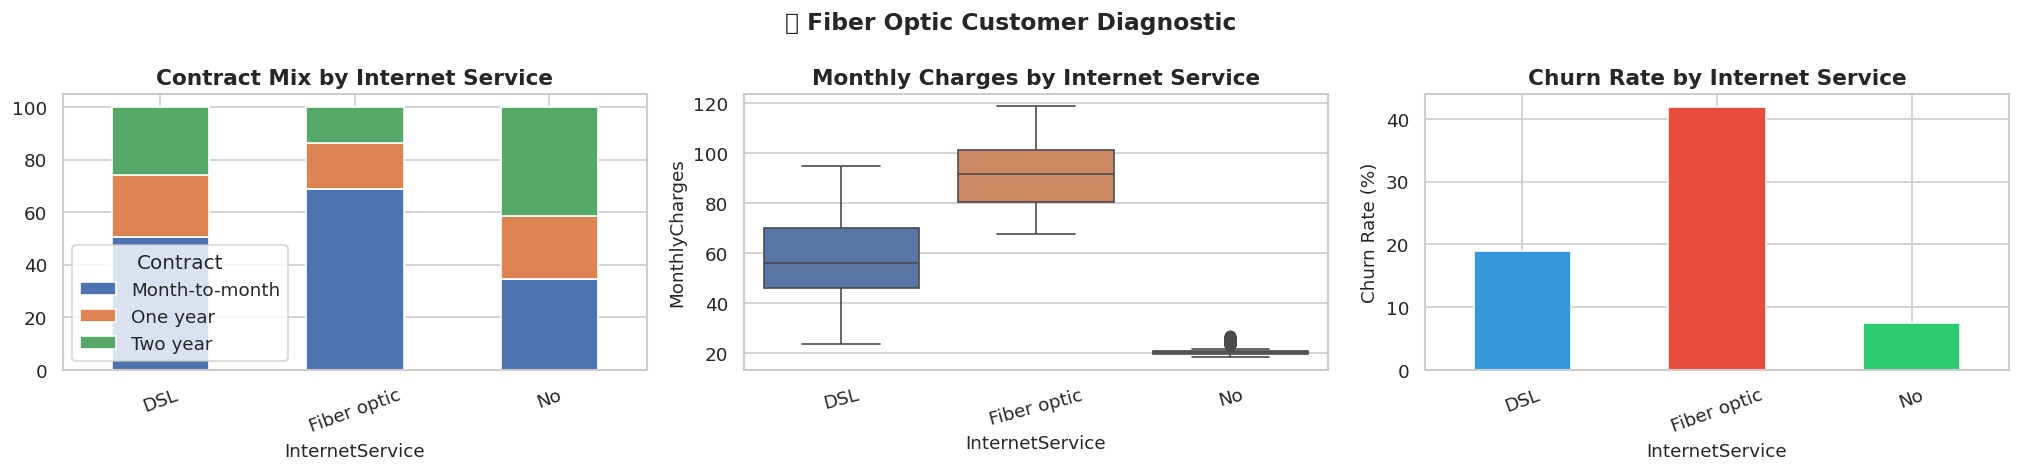

Mann-Whitney U (Fiber vs DSL charges): p = 0.00e+00 → Significant ✅

💡 Fiber Optic customers: higher price + month-to-month contracts = compounding churn risk.


In [ ]:
# ── 5.1 Fiber Optic Deep Dive ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ct1 = pd.crosstab(df["InternetService"], df["Contract"], normalize="index") * 100
ct1.plot(kind="bar", stacked=True, ax=axes[0], edgecolor="white")
axes[0].set_title("Contract Mix by Internet Service")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="InternetService", y="MonthlyCharges", ax=axes[1], palette="deep")
axes[1].set_title("Monthly Charges by Internet Service")
axes[1].tick_params(axis="x", rotation=15)

ct2 = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
ct2["Yes"].plot(kind="bar", ax=axes[2], color=["#3498db","#e74c3c","#2ecc71"], edgecolor="white")
axes[2].set_title("Churn Rate by Internet Service")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].tick_params(axis="x", rotation=20)

plt.suptitle("🔍 Fiber Optic Customer Diagnostic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

_, p = mannwhitneyu(
    df[df["InternetService"] == "Fiber optic"]["MonthlyCharges"],
    df[df["InternetService"] == "DSL"]["MonthlyCharges"]
)
print(f"Mann-Whitney U (Fiber vs DSL charges): p = {p:.2e} → {'Significant ✅' if p < 0.05 else 'Not Significant'}")
print("\n💡 Fiber Optic customers: higher price + month-to-month contracts = compounding churn risk.")


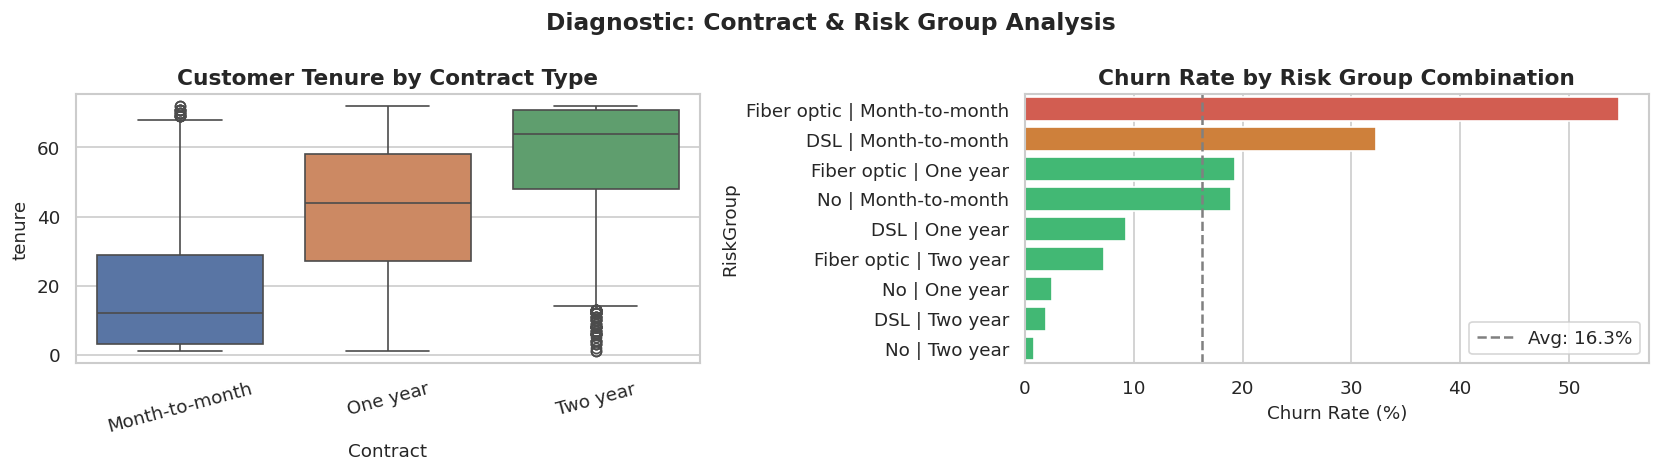


Top 5 highest-risk combinations:


Churn,No,Yes
RiskGroup,,
Fiber optic | Month-to-month,45.394737,54.605263
DSL | Month-to-month,67.784137,32.215863
Fiber optic | One year,80.705009,19.294991
No | Month-to-month,81.106870,18.893130
DSL | One year,90.701754,9.298246


In [ ]:
# ── 5.2 Contract × Tenure Interaction ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x="Contract", y="tenure", palette="deep", ax=axes[0])
axes[0].set_title("Customer Tenure by Contract Type")
axes[0].tick_params(axis="x", rotation=15)

df["RiskGroup"] = df["InternetService"].astype(str) + " | " + df["Contract"].astype(str)
risk_matrix = (
    pd.crosstab(df["RiskGroup"], df["Churn"], normalize="index") * 100
).sort_values("Yes", ascending=False)

colors = ["#e74c3c" if v > 40 else "#e67e22" if v > 20 else "#2ecc71"
          for v in risk_matrix["Yes"]]
sns.barplot(x=risk_matrix["Yes"], y=risk_matrix.index, palette=colors, ax=axes[1])
axes[1].axvline(risk_matrix["Yes"].mean(), linestyle="--", color="gray",
                label=f"Avg: {risk_matrix['Yes'].mean():.1f}%")
axes[1].set_xlabel("Churn Rate (%)")
axes[1].set_title("Churn Rate by Risk Group Combination")
axes[1].legend()

plt.suptitle("Diagnostic: Contract & Risk Group Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 5 highest-risk combinations:")
display(risk_matrix.head(5).style.background_gradient(cmap="RdYlGn_r"))


---
## 6. Customer Segmentation (K-Means Clustering)

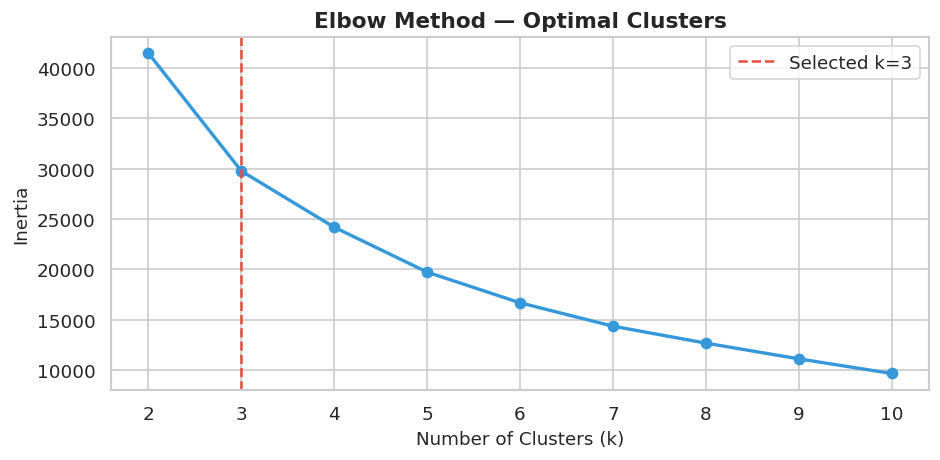

In [ ]:
# ── Prepare & Elbow ───────────────────────────────────────────────────────────
seg_df   = df.copy()
seg_data = pd.get_dummies(
    seg_df[["tenure", "MonthlyCharges", "TotalCharges", "InternetService", "Contract", "OnlineSecurity"]],
    drop_first=True
)
X_seg = StandardScaler().fit_transform(seg_data)

inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_seg)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertia, marker="o", color="#3498db", linewidth=2)
plt.axvline(3, linestyle="--", color="#e74c3c", label="Selected k=3")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal Clusters", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


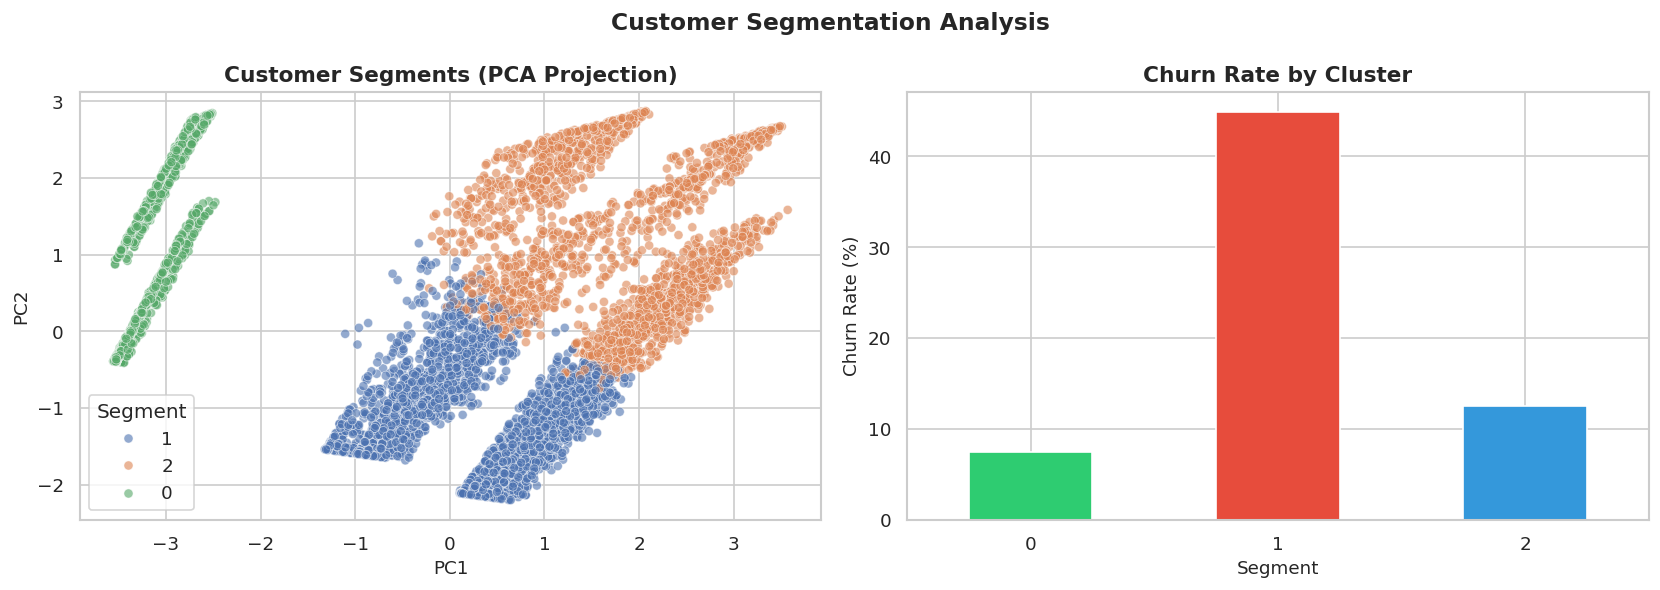

,Tenure_mean,MonthlyCharges,TotalCharges,Count,ChurnRate_%
Segment,,,,,
0,30.6700,21.0800,665.2200,1520,7.4342
1,15.7500,69.9300,1123.2900,3298,44.8757
2,58.4600,87.1700,5122.1500,2214,12.4661



✅ Personas assigned.


In [ ]:
# ── Fit & Profile Segments ────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
seg_df["Segment"] = kmeans.fit_predict(X_seg)

pca      = PCA(n_components=2, random_state=42)
pca_crd  = pca.fit_transform(X_seg)
pca_df   = pd.DataFrame({"PC1": pca_crd[:, 0], "PC2": pca_crd[:, 1],
                          "Segment": seg_df["Segment"].astype(str)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Segment",
                palette="deep", alpha=0.6, ax=axes[0], s=30)
axes[0].set_title("Customer Segments (PCA Projection)")

churn_by_seg = pd.crosstab(seg_df["Segment"], seg_df["Churn"], normalize="index") * 100
churn_by_seg["Yes"].plot(kind="bar", ax=axes[1],
                          color=["#2ecc71","#e74c3c","#3498db"], edgecolor="white")
axes[1].set_title("Churn Rate by Cluster")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Customer Segmentation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

profile = seg_df.groupby("Segment").agg(
    Tenure_mean=("tenure","mean"), MonthlyCharges=("MonthlyCharges","mean"),
    TotalCharges=("TotalCharges","mean"), Count=("tenure","count")
).round(2)
profile["ChurnRate_%"] = churn_by_seg["Yes"].values
display(profile)

persona_map = {0: "💰 Premium Loyal", 1: "⚠️ At-Risk Early", 2: "🟢 Stable Budget"}
seg_df["Persona"] = seg_df["Segment"].map(persona_map)
print("\n✅ Personas assigned.")


---
## 7. Feature Engineering

In [ ]:
# ── Construct Domain Features ─────────────────────────────────────────────────
model_df = seg_df.copy()

model_df["AvgSpendPerMonth"] = model_df["TotalCharges"] / (model_df["tenure"] + 1)

service_cols = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup",
                "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
model_df["ServiceCount"] = model_df[service_cols].eq("Yes").sum(axis=1)

model_df["TenureGroup"]   = pd.cut(model_df["tenure"], bins=[0,12,24,48,72],
                                    labels=["New","Developing","Established","Loyal"])
model_df["ContractRisk"]  = model_df["Contract"].map(
    {"Month-to-month":"High","One year":"Medium","Two year":"Low"})
model_df["InternetRisk"]  = model_df["InternetService"].map(
    {"Fiber optic":"High","DSL":"Medium","No":"Low"})

# Encode target
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

# Drop non-feature columns
DROP_COLS = ["customerID","Persona","RiskGroup","Segment"]
model_df.drop(columns=[c for c in DROP_COLS if c in model_df.columns], inplace=True)

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

print(f"✅ Features ready: {X.shape[1]} total ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"   Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"   Class balance — 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")


✅ Features ready: 24 total (6 numeric, 18 categorical)
   Train: 5,625  |  Test: 1,407
   Class balance — 0: 4,130  |  1: 1,495


---
## 8. AutoML Evaluation Pipeline

### Strategy
1. **Phase 1 — CV-5 Grid** : Evaluate 7 models × 4 imbalance strategies = **28 combinations**
2. **Phase 2 — Optuna Tuning** : Tune top-3 by F1 with **50 trials each**
3. **Phase 3 — Final Evaluation** : Threshold optimization → best model selected

> 📌 Primary metric: **F1 Score** (balances precision/recall for imbalanced churn data)


In [ ]:
# ── 8.1 Define Candidate Models & Strategies ─────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

BASE_MODELS = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, random_state=42,
        eval_metric="logloss", verbosity=0,
        scale_pos_weight=scale_pos),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, random_state=42,
        class_weight="balanced", verbose=-1),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, random_state=42,
        auto_class_weights="Balanced", verbose=0),
    "SVM": SVC(
        probability=True, class_weight="balanced", random_state=42),
}

STRATEGIES = {
    "ClassWeight" : None,           # handled inside model params
    "SMOTE"       : SMOTE(random_state=42),
    "ROS"         : RandomOverSampler(random_state=42),
    "ADASYN"      : ADASYN(random_state=42),
}

print(f"📋 Models    : {list(BASE_MODELS.keys())}")
print(f"📋 Strategies: {list(STRATEGIES.keys())}")
print(f"📋 Total combinations: {len(BASE_MODELS) * len(STRATEGIES)}")


📋 Models    : ['LogisticRegression', 'RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM', 'CatBoost', 'SVM']
📋 Strategies: ['ClassWeight', 'SMOTE', 'ROS', 'ADASYN']
📋 Total combinations: 28


In [ ]:
# ── 8.2 CV-5 Grid Evaluation ──────────────────────────────────────────────────
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Menggunakan string identifier bawaan scikit-learn untuk stabilitas
SCORERS = {
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "precision": "precision"
}

cv_results = []
total = len(BASE_MODELS) * len(STRATEGIES)
idx = 0

print(f"🔄 Running CV-5 on {total} combinations (Iterating via cross_val_score)...\n")
start_all = time.time()

for model_name, base_model in BASE_MODELS.items():
    for strat_name, sampler in STRATEGIES.items():
        idx += 1
        t0 = time.time()

        try:
            # Membangun pipeline berdasarkan strategi penyeimbangan data
            if sampler is not None:
                pipe = ImbPipeline([
                    ("preprocess", preprocessor),
                    ("sampler",    sampler),
                    ("model",      base_model)
                ])
            else:
                pipe = Pipeline([
                    ("preprocess", preprocessor),
                    ("model",      base_model)
                ])

            # Melakukan per-scorer loop menggunakan cross_val_score untuk validasi ketat
            scores_cache = {}
            for metric_key, scorer_name in SCORERS.items():
                scores = cross_val_score(
                    pipe, X_train, y_train,
                    cv=CV,
                    scoring=scorer_name,
                    n_jobs=-1
                )
                scores_cache[metric_key] = scores

            cv_results.append({
                "Model"       : model_name,
                "Strategy"    : strat_name,
                "CV_F1"       : scores_cache["f1"].mean(),
                "CV_Recall"   : scores_cache["recall"].mean(),
                "CV_ROC_AUC"  : scores_cache["roc_auc"].mean(),
                "CV_Precision": scores_cache["precision"].mean(),
                "CV_Std_F1"   : scores_cache["f1"].std(),
            })

            elapsed = time.time() - t0
            print(f"  [{idx:02d}/{total}] {model_name:<20} + {strat_name:<12} "
                  f"F1={scores_cache['f1'].mean():.4f} ± {scores_cache['f1'].std():.4f}  "
                  f"({elapsed:.1f}s)")

        except Exception as e:
            print(f"  [{idx:02d}/{total}] {model_name} + {strat_name} → ERROR: {e}")
            cv_results.append({
                "Model": model_name, "Strategy": strat_name,
                "CV_F1": np.nan, "CV_Recall": np.nan,
                "CV_ROC_AUC": np.nan, "CV_Precision": np.nan, "CV_Std_F1": np.nan
            })

print(f"\n✅ Done in {(time.time()-start_all)/60:.1f} min")

🔄 Running CV-5 on 28 combinations (Iterating via cross_val_score)...

  [01/28] LogisticRegression   + ClassWeight  F1=0.5845 ± 0.0221  (11.3s)
  [02/28] LogisticRegression   + SMOTE        F1=0.6350 ± 0.0078  (5.0s)
  [03/28] LogisticRegression   + ROS          F1=0.6341 ± 0.0051  (4.3s)
  [04/28] LogisticRegression   + ADASYN       F1=0.6235 ± 0.0071  (5.7s)
  [05/28] RandomForest         + ClassWeight  F1=0.5695 ± 0.0210  (32.3s)
  [06/28] RandomForest         + SMOTE        F1=0.5854 ± 0.0209  (54.7s)
  [07/28] RandomForest         + ROS          F1=0.5910 ± 0.0268  (41.5s)
  [08/28] RandomForest         + ADASYN       F1=0.5912 ± 0.0217  (54.2s)
  [09/28] ExtraTrees           + ClassWeight  F1=0.5374 ± 0.0315  (30.8s)
  [10/28] ExtraTrees           + SMOTE        F1=0.5547 ± 0.0273  (43.7s)
  [11/28] ExtraTrees           + ROS          F1=0.5363 ± 0.0232  (37.9s)
  [12/28] ExtraTrees           + ADASYN       F1=0.5536 ± 0.0241  (45.8s)
  [13/28] XGBoost              + ClassWeight 

📊 Full CV-5 Results (sorted by F1):



,Model,Strategy,CV_F1,CV_Recall,CV_ROC_AUC,CV_Precision,CV_Std_F1,Rank
0,LogisticRegression,SMOTE,0.6350,0.7913,0.8482,0.5303,0.0078,1
1,LogisticRegression,ROS,0.6341,0.7987,0.8481,0.5259,0.0051,2
2,CatBoost,ClassWeight,0.6324,0.7625,0.8450,0.5403,0.0140,3
3,SVM,ClassWeight,0.6295,0.7906,0.8269,0.5230,0.0079,4
4,CatBoost,ROS,0.6267,0.7385,0.8418,0.5443,0.0127,5
5,XGBoost,SMOTE,0.6237,0.7538,0.8364,0.5320,0.0188,6
6,LogisticRegression,ADASYN,0.6235,0.8334,0.8466,0.4981,0.0071,7
7,XGBoost,ADASYN,0.6212,0.7572,0.8333,0.5268,0.0158,8
8,SVM,ROS,0.6207,0.7779,0.8232,0.5165,0.0086,9
9,XGBoost,ClassWeight,0.6183,0.7130,0.8372,0.5459,0.0116,10


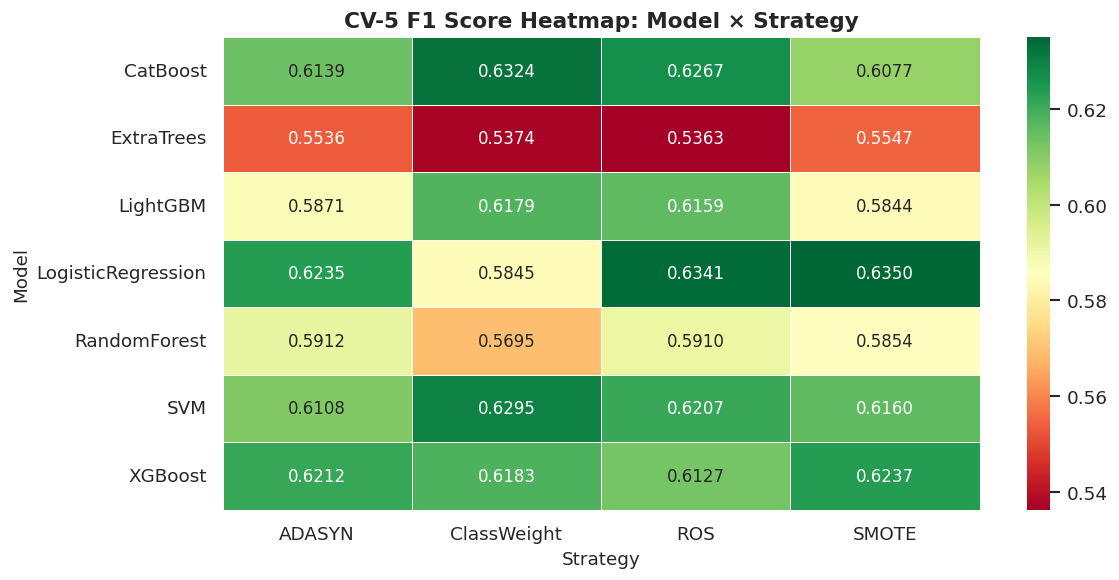


🏆 Top-3 Combinations Selected for Optuna Tuning:


,Model,Strategy,CV_F1,CV_Recall,CV_ROC_AUC,CV_Std_F1
0,LogisticRegression,SMOTE,0.6350,0.7913,0.8482,0.0078
1,LogisticRegression,ROS,0.6341,0.7987,0.8481,0.0051
2,CatBoost,ClassWeight,0.6324,0.7625,0.8450,0.0140


In [ ]:
# ── 8.3 CV Results Summary & Top-3 Selection ─────────────────────────────────
cv_df = pd.DataFrame(cv_results).dropna(subset=["CV_F1"])
cv_df = cv_df.sort_values("CV_F1", ascending=False).reset_index(drop=True)
cv_df["Rank"] = cv_df.index + 1

print("📊 Full CV-5 Results (sorted by F1):\n")
display(
    cv_df.style
    .background_gradient(subset=["CV_F1","CV_Recall","CV_ROC_AUC"], cmap="RdYlGn")
    .format({c: "{:.4f}" for c in ["CV_F1","CV_Recall","CV_ROC_AUC","CV_Precision","CV_Std_F1"]})
    .set_caption("Cross-Validation Results — 28 Combinations")
)

# Heatmap
pivot = cv_df.pivot(index="Model", columns="Strategy", values="CV_F1")
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn", linewidths=0.5,
            annot_kws={"size": 10})
plt.title("CV-5 F1 Score Heatmap: Model × Strategy", fontweight="bold")
plt.tight_layout()
plt.show()

# Select Top-3
top3 = cv_df.head(3)
print("\n🏆 Top-3 Combinations Selected for Optuna Tuning:")
display(top3[["Model","Strategy","CV_F1","CV_Recall","CV_ROC_AUC","CV_Std_F1"]])


In [ ]:
# ── 8.4 Optuna Hyperparameter Tuning (Top-3 Only) ────────────────────────────
def get_sampler(strat_name):
    return {
        "ClassWeight": None,
        "SMOTE"      : SMOTE(random_state=42),
        "ROS"        : RandomOverSampler(random_state=42),
        "ADASYN"     : ADASYN(random_state=42),
    }[strat_name]


def objective_factory(model_name, strat_name):
    """Return an Optuna objective function for a given model + strategy."""

    def objective(trial):
        sampler = get_sampler(strat_name)

        if model_name == "LogisticRegression":
            params = {
                "C"      : trial.suggest_float("C", 0.001, 10.0, log=True),
                "solver" : trial.suggest_categorical("solver", ["lbfgs","saga"]),
                "max_iter": 2000,
                "random_state": 42,
            }
            model = LogisticRegression(**params)

        elif model_name == "RandomForest":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 100, 500, step=50),
                "max_depth"       : trial.suggest_int("max_depth", 3, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features"    : trial.suggest_categorical("max_features", ["sqrt","log2"]),
                "class_weight"    : "balanced",
                "random_state"    : 42,
                "n_jobs"          : -1,
            }
            model = RandomForestClassifier(**params)

        elif model_name == "ExtraTrees":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 100, 500, step=50),
                "max_depth"       : trial.suggest_int("max_depth", 3, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
                "class_weight"    : "balanced",
                "random_state"    : 42,
                "n_jobs"          : -1,
            }
            model = ExtraTreesClassifier(**params)

        elif model_name == "XGBoost":
            params = {
                "n_estimators"   : trial.suggest_int("n_estimators", 100, 600, step=50),
                "max_depth"      : trial.suggest_int("max_depth", 2, 8),
                "learning_rate"  : trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                "subsample"      : trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "gamma"          : trial.suggest_float("gamma", 0, 5),
                "scale_pos_weight": scale_pos,
                "eval_metric"    : "logloss",
                "verbosity"      : 0,
                "random_state"   : 42,
            }
            model = XGBClassifier(**params)

        elif model_name == "LightGBM":
            params = {
                "n_estimators"  : trial.suggest_int("n_estimators", 100, 600, step=50),
                "max_depth"     : trial.suggest_int("max_depth", 2, 12),
                "learning_rate" : trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                "num_leaves"    : trial.suggest_int("num_leaves", 16, 128),
                "subsample"     : trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
                "class_weight"  : "balanced",
                "verbose"       : -1,
                "random_state"  : 42,
            }
            model = LGBMClassifier(**params)

        elif model_name == "CatBoost":
            params = {
                "iterations"   : trial.suggest_int("iterations", 100, 600, step=50),
                "depth"        : trial.suggest_int("depth", 3, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
                "l2_leaf_reg"  : trial.suggest_float("l2_leaf_reg", 1e-3, 10, log=True),
                "auto_class_weights": "Balanced",
                "verbose"      : 0,
                "random_state" : 42,
            }
            model = CatBoostClassifier(**params)

        elif model_name == "SVM":
            params = {
                "C"            : trial.suggest_float("C", 0.01, 100, log=True),
                "kernel"       : trial.suggest_categorical("kernel", ["rbf","linear"]),
                "gamma"        : trial.suggest_categorical("gamma", ["scale","auto"]),
                "class_weight" : "balanced",
                "probability"  : True,
                "random_state" : 42,
            }
            model = SVC(**params)

        # Build pipeline
        if sampler is not None:
            pipe = ImbPipeline([("preprocess", preprocessor),
                                ("sampler", sampler), ("model", model)])
        else:
            pipe = Pipeline([("preprocess", preprocessor), ("model", model)])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_validate(pipe, X_train, y_train, cv=cv,
                                scoring={"f1": make_scorer(f1_score)}, n_jobs=-1)
        return scores["test_f1"].mean()

    return objective


# ── Run tuning for top-3 ──────────────────────────────────────────────────────
OPTUNA_TRIALS = 50
tuning_results = {}

print(f"🔬 Optuna tuning: {OPTUNA_TRIALS} trials × 3 models\n")

for _, row in top3.iterrows():
    model_name = row["Model"]
    strat_name = row["Strategy"]
    key        = f"{model_name}+{strat_name}"

    print(f"  ▶ Tuning: {key} ...")
    t0 = time.time()

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_factory(model_name, strat_name),
                   n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    elapsed = time.time() - t0
    print(f"    Best F1 (CV-5): {study.best_value:.4f}  "
          f"| Best params: {study.best_params}  ({elapsed/60:.1f} min)\n")

    tuning_results[key] = {
        "model_name" : model_name,
        "strat_name" : strat_name,
        "best_cv_f1" : study.best_value,
        "best_params": study.best_params,
        "study"      : study,
    }

print("✅ Optuna tuning complete.")


🔬 Optuna tuning: 50 trials × 3 models

  ▶ Tuning: LogisticRegression+SMOTE ...


  0%|          | 0/50 [00:00<?, ?it/s]

    Best F1 (CV-5): 0.6376  | Best params: {'C': 0.24810409748678125, 'solver': 'lbfgs'}  (2.6 min)

  ▶ Tuning: LogisticRegression+ROS ...


  0%|          | 0/50 [00:00<?, ?it/s]

    Best F1 (CV-5): 0.6347  | Best params: {'C': 0.5941337791982679, 'solver': 'saga'}  (7.7 min)

  ▶ Tuning: CatBoost+ClassWeight ...


  0%|          | 0/50 [00:00<?, ?it/s]

    Best F1 (CV-5): 0.6405  | Best params: {'iterations': 200, 'depth': 4, 'learning_rate': 0.04154322577384011, 'l2_leaf_reg': 0.08783671797355141}  (6.7 min)

✅ Optuna tuning complete.


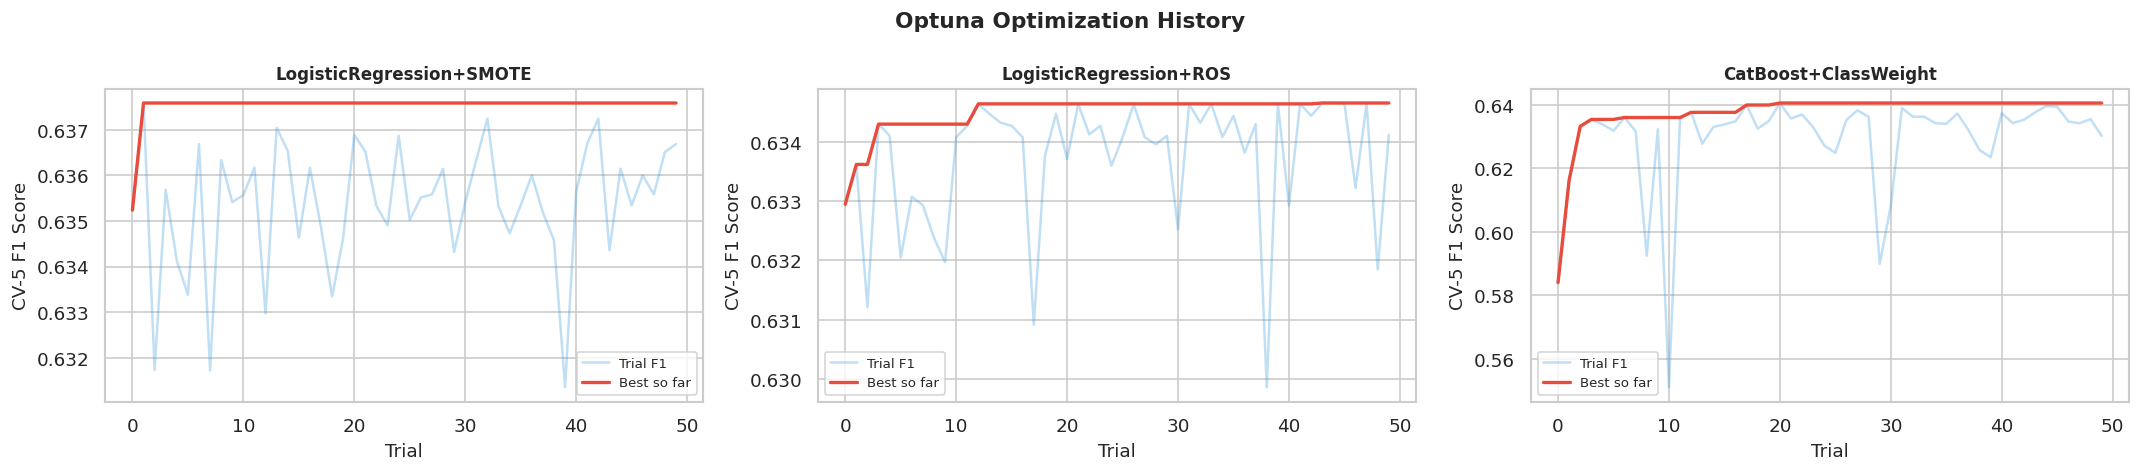

,Combination,Best CV-5 F1,Best Params
2,CatBoost+ClassWeight,0.6405,"{'iterations': 200, 'depth': 4, 'learning_rate..."
0,LogisticRegression+SMOTE,0.6376,"{'C': 0.24810409748678125, 'solver': 'lbfgs'}"
1,LogisticRegression+ROS,0.6347,"{'C': 0.5941337791982679, 'solver': 'saga'}"


In [ ]:
# ── 8.5 Optuna Tuning Results Visualization ──────────────────────────────────
fig, axes = plt.subplots(1, len(tuning_results), figsize=(6 * len(tuning_results), 4))
if len(tuning_results) == 1:
    axes = [axes]

for ax, (key, res) in zip(axes, tuning_results.items()):
    study   = res["study"]
    trials  = [t.number for t in study.trials if t.value is not None]
    values  = [t.value  for t in study.trials if t.value is not None]
    best_so_far = [max(values[:i+1]) for i in range(len(values))]

    ax.plot(trials, values, alpha=0.3, color="#3498db", label="Trial F1")
    ax.plot(trials, best_so_far, color="#e74c3c", linewidth=2, label="Best so far")
    ax.set_title(key, fontsize=10, fontweight="bold")
    ax.set_xlabel("Trial")
    ax.set_ylabel("CV-5 F1 Score")
    ax.legend(fontsize=8)

plt.suptitle("Optuna Optimization History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary table
summary_rows = []
for key, res in tuning_results.items():
    summary_rows.append({
        "Combination"  : key,
        "Best CV-5 F1" : res["best_cv_f1"],
        "Best Params"  : str(res["best_params"])
    })
display(pd.DataFrame(summary_rows).sort_values("Best CV-5 F1", ascending=False))


In [ ]:
# ── 8.6 Retrain Best Tuned Models on Full Train Set & Final Evaluation ────────

def rebuild_model(model_name, params):
    """Rebuild model from name + best params dict."""
    p = params.copy()
    if model_name == "LogisticRegression":
        p.update({"max_iter": 2000, "random_state": 42})
        return LogisticRegression(**p)
    elif model_name == "RandomForest":
        p.update({"class_weight": "balanced", "random_state": 42, "n_jobs": -1})
        return RandomForestClassifier(**p)
    elif model_name == "ExtraTrees":
        p.update({"class_weight": "balanced", "random_state": 42, "n_jobs": -1})
        return ExtraTreesClassifier(**p)
    elif model_name == "XGBoost":
        p.update({"scale_pos_weight": scale_pos, "eval_metric": "logloss",
                  "verbosity": 0, "random_state": 42})
        return XGBClassifier(**p)
    elif model_name == "LightGBM":
        p.update({"class_weight": "balanced", "verbose": -1, "random_state": 42})
        return LGBMClassifier(**p)
    elif model_name == "CatBoost":
        p.update({"auto_class_weights": "Balanced", "verbose": 0, "random_state": 42})
        return CatBoostClassifier(**p)
    elif model_name == "SVM":
        p.update({"class_weight": "balanced", "probability": True, "random_state": 42})
        return SVC(**p)


def build_final_pipeline(model_name, strat_name, params):
    model   = rebuild_model(model_name, params)
    sampler = get_sampler(strat_name)
    if sampler is not None:
        return ImbPipeline([("preprocess", preprocessor),
                            ("sampler", sampler), ("model", model)])
    return Pipeline([("preprocess", preprocessor), ("model", model)])


# Train & evaluate on held-out test set
final_results = []
trained_pipelines = {}

for key, res in tuning_results.items():
    pipe = build_final_pipeline(res["model_name"], res["strat_name"], res["best_params"])
    pipe.fit(X_train, y_train)
    trained_pipelines[key] = pipe

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    # Threshold optimization
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1s = [f1_score(y_test, (prob >= t).astype(int)) for t in thresholds]
    best_t  = thresholds[np.argmax(f1s)]
    pred_opt = (prob >= best_t).astype(int)

    final_results.append({
        "Combination"     : key,
        "CV-5 F1 (tuned)" : res["best_cv_f1"],
        "Test Accuracy"   : accuracy_score(y_test, pred_opt),
        "Test Precision"  : precision_score(y_test, pred_opt),
        "Test Recall"     : recall_score(y_test, pred_opt),
        "Test F1"         : f1_score(y_test, pred_opt),
        "Test ROC-AUC"    : roc_auc_score(y_test, prob),
        "Optimal Threshold": best_t,
        "_pipe"           : pipe,
        "_prob"           : prob,
        "_threshold"      : best_t,
    })

final_df = pd.DataFrame(final_results).sort_values("Test F1", ascending=False)

display_cols = ["Combination","CV-5 F1 (tuned)","Test Accuracy","Test Precision",
                "Test Recall","Test F1","Test ROC-AUC","Optimal Threshold"]
display(
    final_df[display_cols].style
    .highlight_max(axis=0, color="#d4edda")
    .format({c: "{:.4f}" for c in display_cols if c not in ["Combination"]})
    .set_caption("Final Evaluation — Tuned Top-3 Models on Held-Out Test Set")
)


,Combination,CV-5 F1 (tuned),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Optimal Threshold
2,CatBoost+ClassWeight,0.6405,0.7811,0.5724,0.6979,0.6289,0.8398,0.6200
0,LogisticRegression+SMOTE,0.6376,0.7719,0.5542,0.7246,0.6280,0.8355,0.5800
1,LogisticRegression+ROS,0.6347,0.7640,0.5407,0.7460,0.6270,0.8371,0.5700


🏆 Champion Model   : CatBoost+ClassWeight
   Test F1          : 0.6289
   Test ROC-AUC     : 0.8398
   Test Recall      : 0.6979
   Optimal Threshold: 0.62


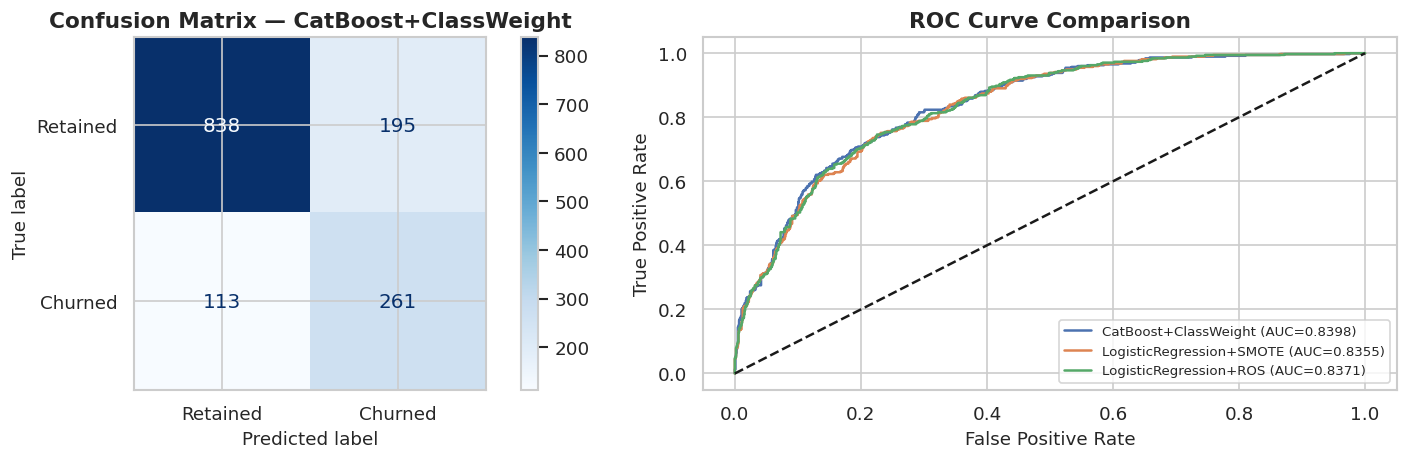

In [ ]:
# ── 8.7 Pick Champion Model ───────────────────────────────────────────────────
best_row        = final_df.iloc[0]
BEST_KEY        = best_row["Combination"]
BEST_PIPELINE   = best_row["_pipe"]
BEST_PROB       = best_row["_prob"]
BEST_THRESHOLD  = best_row["_threshold"]

print(f"🏆 Champion Model   : {BEST_KEY}")
print(f"   Test F1          : {best_row['Test F1']:.4f}")
print(f"   Test ROC-AUC     : {best_row['Test ROC-AUC']:.4f}")
print(f"   Test Recall      : {best_row['Test Recall']:.4f}")
print(f"   Optimal Threshold: {BEST_THRESHOLD:.2f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, (BEST_PROB >= BEST_THRESHOLD).astype(int),
    display_labels=["Retained","Churned"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix — {BEST_KEY}", fontweight="bold")

# ROC comparison
for key, res in final_df.set_index("Combination")[["_pipe","_prob"]].iterrows():
    fpr = []
    tpr = []
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, res["_prob"])
    auc = roc_auc_score(y_test, res["_prob"])
    axes[1].plot(fpr, tpr, label=f"{key} (AUC={auc:.4f})")

axes[1].plot([0,1],[0,1],"k--")
axes[1].set_title("ROC Curve Comparison")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 9. Explainable AI (SHAP)

Explaining the champion model's decisions to business stakeholders.

In [ ]:
# ── Extract preprocessor + model from champion pipeline ───────────────────────
# Works for both Pipeline and ImbPipeline
steps = dict(BEST_PIPELINE.steps)
preproc_fitted = steps["preprocess"]
clf            = steps["model"]

feature_names  = preproc_fitted.get_feature_names_out()
X_test_t       = preproc_fitted.transform(X_test)

# Use TreeExplainer for tree-based; KernelExplainer fallback for others
tree_models = (RandomForestClassifier, ExtraTreesClassifier,
               XGBClassifier, LGBMClassifier, CatBoostClassifier)

if isinstance(clf, tree_models):
    explainer   = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_t)
    shap_churn  = shap_values[1] if isinstance(shap_values, list) else shap_values
    print(f"✅ TreeExplainer used for {type(clf).__name__}")
else:
    # Kernel for LR / SVM — use a small background sample
    background  = shap.sample(X_test_t, 100, random_state=42)
    explainer   = shap.KernelExplainer(
        lambda x: clf.predict_proba(x)[:, 1], background)
    shap_values = explainer.shap_values(X_test_t[:200])
    shap_churn  = shap_values
    X_test_t    = X_test_t[:200]
    print(f"✅ KernelExplainer used for {type(clf).__name__} (sampled 200 rows)")


✅ TreeExplainer used for CatBoostClassifier


📊 SHAP Summary — Global Feature Importance


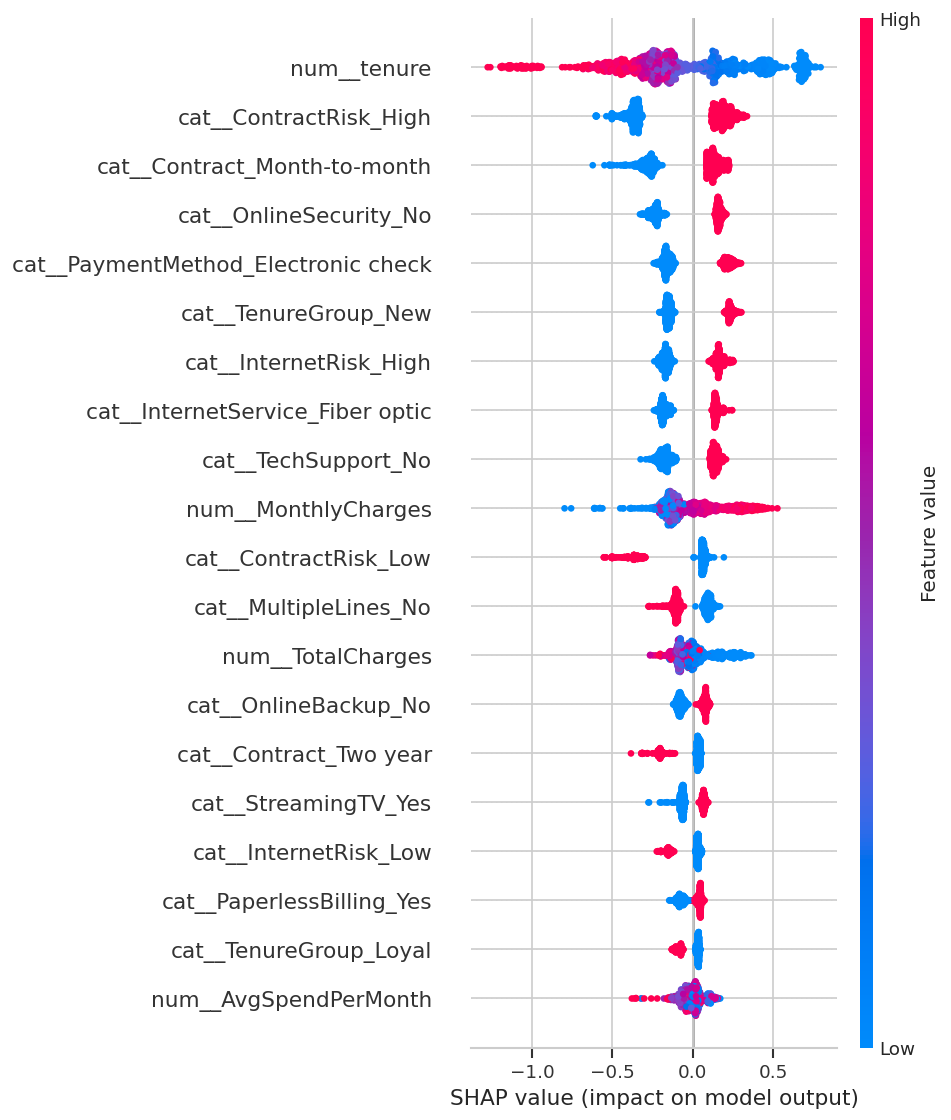

In [ ]:
# ── SHAP Summary Plot ─────────────────────────────────────────────────────────
print("📊 SHAP Summary — Global Feature Importance")
shap.summary_plot(shap_churn, X_test_t, feature_names=feature_names,
                  max_display=20, show=True)


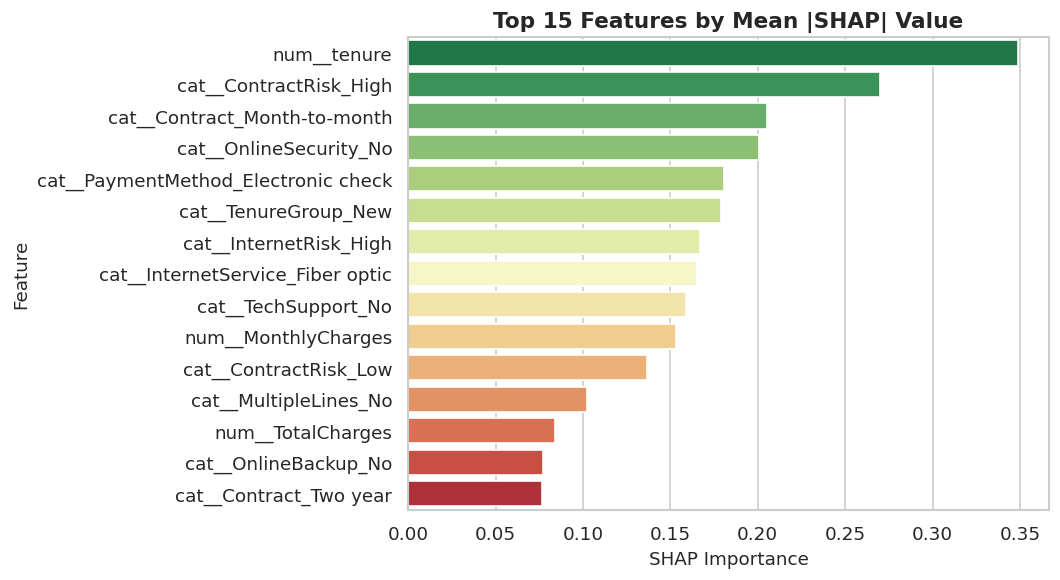

,Feature,SHAP Importance
1,num__tenure,0.3490
51,cat__ContractRisk_High,0.2697
38,cat__Contract_Month-to-month,0.2053
20,cat__OnlineSecurity_No,0.2009
45,cat__PaymentMethod_Electronic check,0.1808
50,cat__TenureGroup_New,0.1788
54,cat__InternetRisk_High,0.1669
18,cat__InternetService_Fiber optic,0.1654
29,cat__TechSupport_No,0.1591
2,num__MonthlyCharges,0.1535


In [ ]:
# ── SHAP Bar Chart (Top 15) ───────────────────────────────────────────────────
mean_shap = np.abs(shap_churn).mean(axis=0)
imp_df = (
    pd.DataFrame({"Feature": feature_names, "SHAP Importance": mean_shap})
    .sort_values("SHAP Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=imp_df, x="SHAP Importance", y="Feature", palette="RdYlGn_r")
plt.title("Top 15 Features by Mean |SHAP| Value", fontweight="bold")
plt.tight_layout()
plt.show()

display(imp_df)


---
## 10. Revenue-at-Risk Analysis

In [ ]:
# ── Build Risk Scoring Dataset ────────────────────────────────────────────────
risk_df = X_test.copy().reset_index(drop=True)
risk_df["churn_probability"] = BEST_PROB
risk_df["churn_prediction"]  = (BEST_PROB >= BEST_THRESHOLD).astype(int)
risk_df["actual_churn"]      = y_test.reset_index(drop=True)

def assign_risk(p):
    if p >= 0.7 : return "🔴 High Risk"
    elif p >= 0.4: return "🟡 Medium Risk"
    else         : return "🟢 Low Risk"

risk_df["risk_segment"]  = risk_df["churn_probability"].apply(assign_risk)
risk_df["expected_loss"] = risk_df["churn_probability"] * risk_df["MonthlyCharges"]

total_loss  = risk_df["expected_loss"].sum()
high_count  = (risk_df["risk_segment"] == "🔴 High Risk").sum()
med_count   = (risk_df["risk_segment"] == "🟡 Medium Risk").sum()

print("=" * 55)
print(f"  💸 Expected Monthly Revenue at Risk: ${total_loss:,.0f}")
print(f"  🔴 High Risk Customers   : {high_count:,}")
print(f"  🟡 Medium Risk Customers : {med_count:,}")
print("=" * 55)


  💸 Expected Monthly Revenue at Risk: $42,142
  🔴 High Risk Customers   : 342
  🟡 Medium Risk Customers : 364


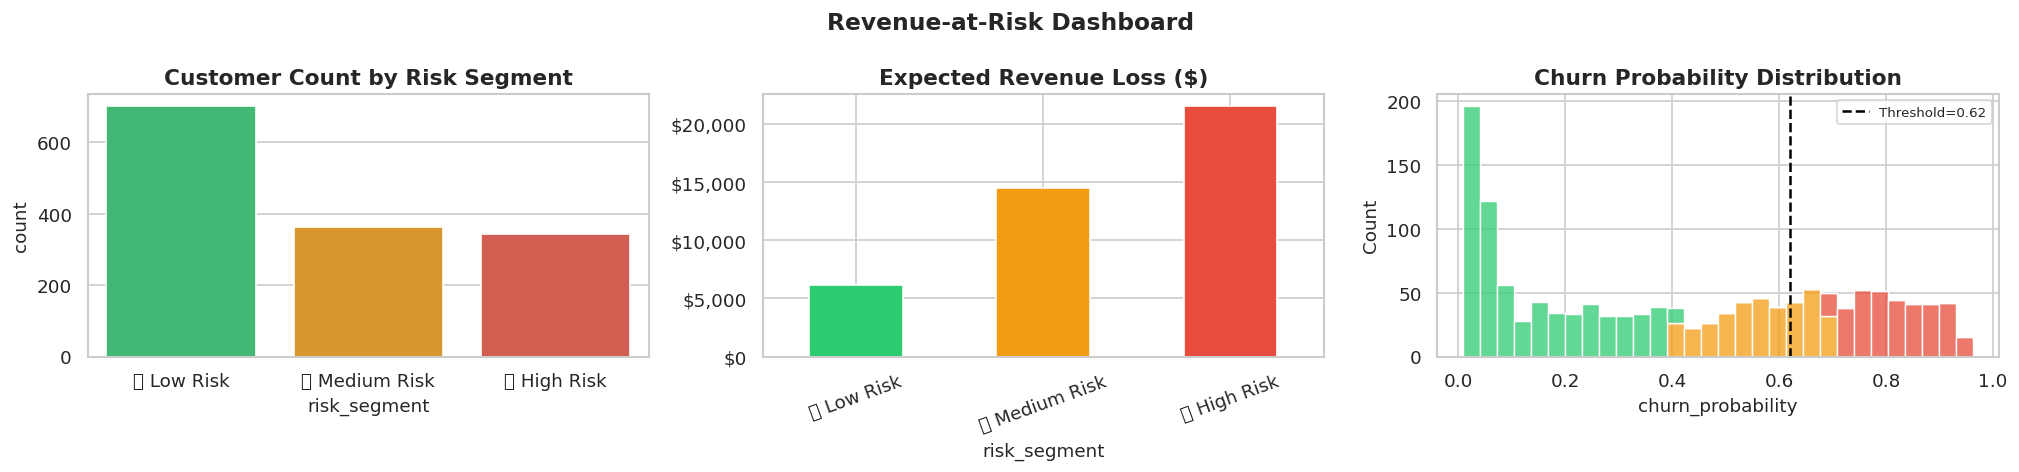


📋 Segment Profile:


,Count,Avg_ChurnProb,Avg_MonthlyCharges,Total_ExpectedLoss
risk_segment,,,,
🟢 Low Risk,701,14.19%,$54.33,"$6,113"
🟡 Medium Risk,364,56.45%,$70.48,"$14,494"
🔴 High Risk,342,81.70%,$76.91,"$21,534"


In [ ]:
# ── Risk Visualization ────────────────────────────────────────────────────────
order   = ["🟢 Low Risk","🟡 Medium Risk","🔴 High Risk"]
palette = {"🟢 Low Risk":"#2ecc71","🟡 Medium Risk":"#f39c12","🔴 High Risk":"#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.countplot(data=risk_df, x="risk_segment", order=order, palette=palette, ax=axes[0])
axes[0].set_title("Customer Count by Risk Segment")

loss_by_seg = risk_df.groupby("risk_segment")["expected_loss"].sum().reindex(order)
loss_by_seg.plot(kind="bar", ax=axes[1],
                 color=["#2ecc71","#f39c12","#e74c3c"], edgecolor="white")
axes[1].set_title("Expected Revenue Loss ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=20)

sns.histplot(data=risk_df, x="churn_probability", hue="risk_segment",
             bins=30, multiple="stack", palette=palette, ax=axes[2])
axes[2].axvline(BEST_THRESHOLD, linestyle="--", color="black",
                label=f"Threshold={BEST_THRESHOLD:.2f}")
axes[2].set_title("Churn Probability Distribution")
axes[2].legend(fontsize=8)

plt.suptitle("Revenue-at-Risk Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📋 Segment Profile:")
display(
    risk_df.groupby("risk_segment")
    .agg(Count=("churn_probability","count"),
         Avg_ChurnProb=("churn_probability","mean"),
         Avg_MonthlyCharges=("MonthlyCharges","mean"),
         Total_ExpectedLoss=("expected_loss","sum"))
    .reindex(order)
    .style.background_gradient(cmap="RdYlGn_r", subset=["Avg_ChurnProb","Total_ExpectedLoss"])
    .format({"Avg_ChurnProb":"{:.2%}","Avg_MonthlyCharges":"${:.2f}","Total_ExpectedLoss":"${:,.0f}"})
)


In [ ]:
# ── Top 20 Highest-Risk Customers ─────────────────────────────────────────────
top_20 = (
    risk_df.sort_values("churn_probability", ascending=False)
    .head(20)
    [["churn_probability","MonthlyCharges","expected_loss","risk_segment","actual_churn"]]
)

display(
    top_20.style
    .background_gradient(subset=["churn_probability"], cmap="RdYlGn_r")
    .background_gradient(subset=["expected_loss"], cmap="Reds")
    .format({"churn_probability":"{:.1%}","MonthlyCharges":"${:.2f}","expected_loss":"${:.2f}"})
)


,churn_probability,MonthlyCharges,expected_loss,risk_segment,actual_churn
1149,96.3%,$95.10,$91.55,🔴 High Risk,1
1080,95.2%,$85.05,$80.98,🔴 High Risk,1
1285,94.5%,$93.30,$88.16,🔴 High Risk,1
902,94.1%,$100.95,$95.03,🔴 High Risk,1
369,94.1%,$69.60,$65.52,🔴 High Risk,1
211,94.1%,$94.85,$89.27,🔴 High Risk,0
988,93.9%,$88.35,$82.99,🔴 High Risk,1
115,93.9%,$89.55,$84.09,🔴 High Risk,1
805,93.9%,$77.15,$72.41,🔴 High Risk,1
984,93.7%,$96.60,$90.56,🔴 High Risk,1


---
## 11. Export Dashboard Dataset

In [ ]:
# ── Multi-sheet Excel Export ──────────────────────────────────────────────────
OUTPUT = "customer_churn_intelligence_dashboard.xlsx"

# Full CV results for Power BI
cv_export = cv_df.drop(columns=["Rank"], errors="ignore")

# Model comparison
model_comparison = final_df[display_cols].copy()

# Feature importance
feat_imp = imp_df.copy()

# Executive summary
exec_summary = pd.DataFrame({
    "Metric": [
        "Champion Model",
        "Imbalance Strategy",
        "CV-5 F1 (tuned)",
        "Test F1",
        "Test ROC-AUC",
        "Test Recall",
        "Optimal Threshold",
        "Customers Evaluated",
        "Predicted Churners",
        "High Risk Customers",
        "Medium Risk Customers",
        "Expected Monthly Revenue at Risk ($)",
    ],
    "Value": [
        BEST_KEY.split("+")[0],
        BEST_KEY.split("+")[1],
        f"{best_row['CV-5 F1 (tuned)']:.4f}",
        f"{best_row['Test F1']:.4f}",
        f"{best_row['Test ROC-AUC']:.4f}",
        f"{best_row['Test Recall']:.4f}",
        f"{BEST_THRESHOLD:.2f}",
        len(risk_df),
        int(risk_df["churn_prediction"].sum()),
        high_count,
        med_count,
        f"${total_loss:,.0f}",
    ]
})

with pd.ExcelWriter(OUTPUT, engine="openpyxl") as writer:
    exec_summary  .to_excel(writer, sheet_name="ExecutiveSummary",   index=False)
    risk_df       .to_excel(writer, sheet_name="ChurnRiskScores",     index=False)
    cv_export     .to_excel(writer, sheet_name="CV_GridResults",      index=False)
    model_comparison.to_excel(writer, sheet_name="ModelComparison",   index=False)
    feat_imp      .to_excel(writer, sheet_name="FeatureImportance",   index=False)

print(f"✅ Dashboard exported → {OUTPUT}")
print("\n📋 Sheets: ExecutiveSummary | ChurnRiskScores | CV_GridResults | ModelComparison | FeatureImportance")


✅ Dashboard exported → customer_churn_intelligence_dashboard.xlsx

📋 Sheets: ExecutiveSummary | ChurnRiskScores | CV_GridResults | ModelComparison | FeatureImportance


---

## 📋 Executive Summary

### 🔄 Pipeline Completed

| Phase | Description | Output |
|-------|-------------|--------|
| Phase 1 | CV-5 Grid — 7 models × 4 strategies | 28 F1 scores + heatmap |
| Phase 2 | Optuna tuning — Top-3 × 50 trials | Best hyperparameters |
| Phase 3 | Final evaluation + threshold optimization | Champion model |

### 🏆 Champion Model
> Selected automatically by highest Test F1 after Optuna tuning

### 💡 Recommended Retention Actions

1. **Onboarding Program** — Dedicated engagement for customers in first 12 months
2. **Contract Incentives** — Discounts to convert month-to-month → annual plans
3. **Fiber Retention Plan** — Proactive outreach to high-cost Fiber Optic subscribers
4. **Bundle Promotions** — Push security & backup add-ons to increase service stickiness
5. **Weekly Risk Scoring** — Automate pipeline output for CRM / customer success teams

---
*Customer Churn Intelligence System · Data Science & AI Engineering Pipeline*
